In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

from config import SEED

## Carga de datos

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [3]:
dataset = 'bp_wd2'

# Datos aumentados

## Imagenes

In [4]:
train_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/train_imgs'
val_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/val_imgs'
test_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/test_imgs'

In [5]:
X_train, y_train = load_image_dataset(train_dir, target_size=(372, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(372, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

In [7]:
indices = np.arange(len(X_train))
np.random.shuffle(indices)

X_train = X_train[indices]
y_train = y_train[indices]

indices_val = np.arange(len(X_val))
np.random.shuffle(indices_val)

X_val = X_val[indices_val]
y_val = y_val[indices_val]

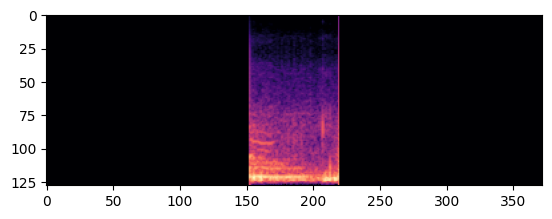

In [13]:
plt.imshow(X_train[2]);

### Transfer Learning

In [14]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 372, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_16444\184640210.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [15]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1e-3,
    decay_steps=9000,
    end_learning_rate=1e-7,
    power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(),#learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 205s 588ms/step - auc: 0.5622 - loss: 0.6952 - recall: 0.5541 - val_auc: 0.6124 - val_loss: 0.6795 - val_recall: 0.8567
Epoch 2/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 232s 677ms/step - auc: 0.6043 - loss: 0.6751 - recall: 0.5935 - val_auc: 0.6344 - val_loss: 0.6627 - val_recall: 0.7287
Epoch 3/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 235s 697ms/step - auc: 0.6279 - loss: 0.6661 - recall: 0.6027 - val_auc: 0.6540 - val_loss: 0.6588 - val_recall: 0.7325
Epoch 4/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 210s 623ms/step - auc: 0.6343 - loss: 0.6620 - recall: 0.5806 - val_auc: 0.6623 - val_loss: 0.6544 - val_recall: 0.6585
Epoch 5/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 214s 636ms/step - auc: 0.6516 - loss: 0.6541 - recall: 0.6105 - val_auc: 0.6618 - val_loss: 0.6515 - val_recall: 0.5816
Epoch 6/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 253s 609ms/step - auc: 0.6627 - loss: 0.6489 - recall: 0.6173 - val_auc: 0.6645 - val_loss: 0.6638 - val_recall: 0.3666
Epoch 7/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 

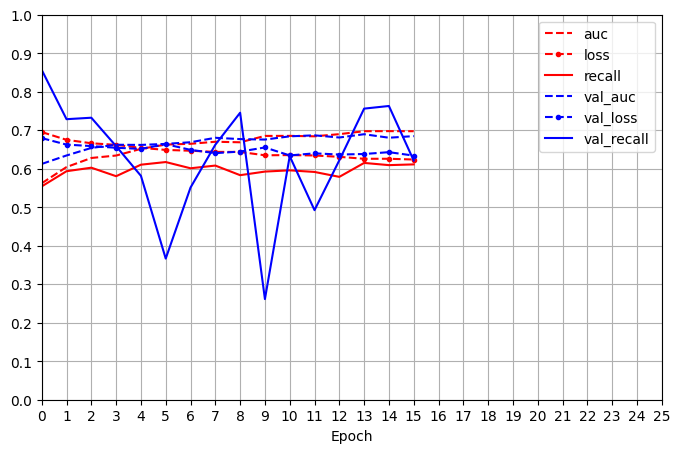

In [19]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 25], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 26), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [20]:
model.evaluate(X_test, y_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 46s 448ms/step - auc: 0.6587 - loss: 0.6518 - recall: 0.5980


[0.6517511606216431, 0.6586862206459045, 0.5979772210121155]

In [21]:
model.save(f'./neural_network/modelos/{dataset}.keras')

### Fine-Tunning

In [22]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [23]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,291,333 (12.56 MB)

 Trainable params: 2,025,793 (7.73 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 688,900 (2.63 MB)

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [25]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [26]:
history_fine_tunning = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop_fine])

Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 274s 781ms/step - auc_1: 0.6112 - loss: 0.7338 - recall_1: 0.4324 - val_auc_1: 0.6524 - val_loss: 0.7554 - val_recall_1: 0.1349
Epoch 2/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 282s 837ms/step - auc_1: 0.6624 - loss: 0.6513 - recall_1: 0.5710 - val_auc_1: 0.6650 - val_loss: 0.6776 - val_recall_1: 0.3209
Epoch 3/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 287s 851ms/step - auc_1: 0.6909 - loss: 0.6306 - recall_1: 0.5931 - val_auc_1: 0.6695 - val_loss: 0.6485 - val_recall_1: 0.5450
Epoch 4/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 299s 887ms/step - auc_1: 0.7139 - loss: 0.6152 - recall_1: 0.6232 - val_auc_1: 0.6845 - val_loss: 0.6473 - val_recall_1: 0.4779
Epoch 5/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 284s 843ms/step - auc_1: 0.7267 - loss: 0.6070 - recall_1: 0.6272 - val_auc_1: 0.6953 - val_loss: 0.6406 - val_recall_1: 0.4497
Epoch 6/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 294s 871ms/step - auc_1: 0.7391 - loss: 0.5972 - recall_1: 0.6482 - val_auc_1: 0.7032 - val_loss: 0.6222 - val_recall_1:

In [27]:
model.evaluate(X_test, y_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 60s 591ms/step - auc_1: 0.7096 - loss: 0.6360 - recall_1: 0.5828


[0.6359831094741821, 0.7095803618431091, 0.5828065872192383]

In [28]:
model.save(f'./neural_network/modelos/{dataset}_fine_tuned.keras')

## Arrays

In [29]:
train_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

val_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram.npz')
X_val = val_data['X']
y_val = val_data['y']

test_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [30]:
X_train = X_train.reshape(-1, 128, 372, 1)
X_val = X_val.reshape(-1, 128, 372, 1)
X_test = X_test.reshape(-1, 128, 372, 1)

In [31]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

In [32]:
indices = np.arange(len(X_train))
np.random.shuffle(indices)
X_train = X_train[indices]
y_train = y_train[indices]

### Transfer Learning

In [33]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 372, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_16444\182398130.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [34]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [36]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [37]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 345s 975ms/step - auc_2: 0.5775 - loss: 0.6895 - recall_2: 0.5438 - val_auc_2: 0.6207 - val_loss: 0.6715 - val_recall_2: 0.7340
Epoch 2/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 311s 924ms/step - auc_2: 0.6115 - loss: 0.6731 - recall_2: 0.5783 - val_auc_2: 0.6365 - val_loss: 0.6635 - val_recall_2: 0.6806
Epoch 3/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 301s 894ms/step - auc_2: 0.6275 - loss: 0.6674 - recall_2: 0.5712 - val_auc_2: 0.6336 - val_loss: 0.6694 - val_recall_2: 0.3155
Epoch 4/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 298s 885ms/step - auc_2: 0.6446 - loss: 0.6595 - recall_2: 0.5869 - val_auc_2: 0.6536 - val_loss: 0.6552 - val_recall_2: 0.5069
Epoch 5/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 278s 754ms/step - auc_2: 0.6465 - loss: 0.6586 - recall_2: 0.5697 - val_auc_2: 0.6607 - val_loss: 0.6621 - val_recall_2: 0.8483
Epoch 6/50
337/337 ━━━━━━━━━━━━━━━━━━━━ 253s 752ms/step - auc_2: 0.6495 - loss: 0.6560 - recall_2: 0.5789 - val_auc_2: 0.6681 - val_loss: 0.6490 - val_recall_2:

In [38]:
model_melspec.evaluate(X_test, y_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 53s 521ms/step - auc_2: 0.6692 - loss: 0.6449 - recall_2: 0.5645


[0.6449084877967834, 0.6692438721656799, 0.5644753575325012]

In [39]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec.keras')

### Fine Tunning

In [40]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [41]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [42]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [ ]:
history_melspec_fine_tunning = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_fine]
    )

In [44]:
model_melspec.evaluate(X_test, y_test)

102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 528ms/step - auc_3: 0.6489 - loss: 0.6584 - recall_3: 0.5392


[0.6584352254867554, 0.6488814353942871, 0.5391908884048462]

In [61]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec_fine_tuned.keras')